# Experiment 10 – Detection + Kalman Filter Tracking Pipeline



---
## Part 1 — Environment Setup & Data Preparation


In [ ]:
#1. Connecting the drive with KITTI dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#2. Cloning into OpenPCDet which is from mmdetection and helps us run the pre-trained PointRCNN library
import os

if not os.path.exists('OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git
%cd OpenPCDet

Cloning into 'OpenPCDet'...
remote: Enumerating objects: 4175, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 4175 (delta 0), reused 0 (delta 0), pack-reused 4170 (from 2)
Receiving objects: 100% (4175/4175), 4.21 MiB | 24.91 MiB/s, done.
Resolving deltas: 100% (2448/2448), done.
/content/OpenPCDet


In [ ]:
#3. Setting up the environment for execution of the mmdet library
import os

print("1. Installing CUDA 11.8...")
!apt-get update > /dev/null
!apt-get install -y cuda-toolkit-11-8 > /dev/null
os.environ["CUDA_HOME"] = "/usr/local/cuda-11.8"

print("\n2. Installing PyTorch cu118...")
!pip install torch==2.2.1 torchvision==0.17.1 torchaudio==2.2.1 --index-url https://download.pytorch.org/whl/cu118 > /dev/null

print("\n3. Installing spconv and cumm...")
!pip uninstall -y spconv spconv-cu118 cumm cumm-cu118 > /dev/null
!pip install --upgrade cumm-cu118 spconv-cu118 > /dev/null

# Disable JIT to prevent compilation errors
os.environ["SPCONV_DISABLE_JIT"] = "1"
os.environ["CUMM_DISABLE_JIT"] = "1"

print("\n4. Setting up OpenPCDet...")
if not os.path.exists('/content/OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git

!pip install tensorboardX easydict pyyaml scikit-image tqdm SharedArray numba > /dev/null
!cd /content/OpenPCDet && pip install av2 && pip install -r requirements.txt > /dev/null
!cd /content/OpenPCDet && python setup.py develop

# Fix for NumPy 2.0 compatibility issues - enforced at the end
print("\nInstalling compatible NumPy version (1.26.4)...")
!pip install "numpy<2.0.0" --force-reinstall > /dev/null
!pip install open3d
print("\n5. Testing spconv import...")
import spconv
print("spconv installed successfully! Version:", spconv.__version__)

1. Installing CUDA 11.8...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%

2. Installing PyTorch cu118...

3. Installing spconv and cumm...

4. Setting up OpenPCDet...
Cloning into 'OpenPCDet'...
remote: Enumerating objects: 4175, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 4175 (delta 0), reused 0 (delta 0), pack-reused 4170 (from 2)
Receiving objects: 100% (4175/4175), 4.21 MiB | 31.68 MiB/s, done.
Resolving deltas: 100% (2452/2452), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.9 MB/s et


5. Testing spconv import...
spconv installed successfully! Version: 2.3.8


In [ ]:
#4. Setting up the dataset symlink
import os
import shutil

# Replace 'path_to_kitti' with your actual path in Drive
drive_kitti_path = '/content/drive/MyDrive/Kitti_tracking'
local_kitti_path = '/content/OpenPCDet/data/kitti'

os.makedirs('/content/OpenPCDet/data', exist_ok=True)

# Remove existing local_kitti_path if it's not a symlink or if it's a broken symlink
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path) or os.path.isdir(local_kitti_path):
        print(f"Removing existing {local_kitti_path}")
        if os.path.islink(local_kitti_path):
            os.unlink(local_kitti_path)
        else:
            shutil.rmtree(local_kitti_path)

# Create a new symlink
if not os.path.exists(local_kitti_path):
    os.symlink(drive_kitti_path, local_kitti_path)
    print("Symlink created for KITTI dataset.")
else:
    print("KITTI dataset path already exists and is valid.")

# Verify the symlink content by listing some directories
print(f"Verifying contents of {local_kitti_path}/training:")
if os.path.exists(os.path.join(local_kitti_path, 'training')):
    print(os.listdir(os.path.join(local_kitti_path, 'training')))
else:
    print(f"Directory not found: {local_kitti_path}/training")

Removing existing /content/OpenPCDet/data/kitti
Symlink created for KITTI dataset.
Verifying contents of /content/OpenPCDet/data/kitti/training:
['calib', 'label_02', 'image_02', 'velodyne']


In [ ]:
#5. Convert KITTI tracking format to detection format
import os
import glob
import shutil
from tqdm import tqdm

# Paths
drive_kitti_path = '/content/drive/MyDrive/Kitti_tracking'
src_base = '/content/OpenPCDet/data/kitti_tracking'
dst_base = '/content/OpenPCDet/data/kitti_det_format'

# Create a stable symlink for the original tracking data
if not os.path.exists(src_base):
    if os.path.islink(src_base):
        os.unlink(src_base)
    os.symlink(drive_kitti_path, src_base)

# Clean up destination to avoid messy states from previous runs
if os.path.exists(dst_base):
    shutil.rmtree(dst_base)
os.makedirs(dst_base, exist_ok=True)
os.makedirs(os.path.join(dst_base, 'ImageSets'), exist_ok=True)

def process_tracking_label(label_path, dst_label_dir, seq_id):
    with open(label_path, 'r') as f:
        lines = f.readlines()

    frame_dict = {}
    for line in lines:
        parts = line.strip().split(' ')
        if len(parts) < 15: continue

        frame_idx = int(parts[0])
        det_line = ' '.join([parts[2]] + parts[3:]) + '\n'

        if frame_idx not in frame_dict:
            frame_dict[frame_idx] = []
        frame_dict[frame_idx].append(det_line)

    for frame_idx, det_lines in frame_dict.items():
        global_idx = f"{int(seq_id):04d}{frame_idx:04d}"
        out_path = os.path.join(dst_label_dir, f"{global_idx}.txt")

        # OpenPCDet bug fix: DontCare objects MUST be at the bottom of the file
        det_lines.sort(key=lambda x: 1 if x.startswith('DontCare') else 0)

        with open(out_path, 'w') as f:
            f.writelines(det_lines)

def convert_tracking_to_detection(split='training'):
    print(f"Converting {split} set...")
    src_split = os.path.join(src_base, split)
    dst_split = os.path.join(dst_base, split)

    src_velo = os.path.join(src_split, 'velodyne')
    src_image = os.path.join(src_split, 'image_02')
    src_calib = os.path.join(src_split, 'calib')
    src_label = os.path.join(src_split, 'label_02')

    dst_velo = os.path.join(dst_split, 'velodyne')
    dst_image = os.path.join(dst_split, 'image_2')
    dst_calib = os.path.join(dst_split, 'calib')
    dst_label = os.path.join(dst_split, 'label_2')

    for d in [dst_velo, dst_image, dst_calib, dst_label]:
        os.makedirs(d, exist_ok=True)

    if not os.path.exists(src_velo):
        print(f"Source velodyne not found: {src_velo}")
        return

    seqs = sorted(os.listdir(src_velo))

    train_frames = []
    val_frames = []

    for seq in tqdm(seqs, desc=f"Processing {split} sequences"):
        if not os.path.isdir(os.path.join(src_velo, seq)): continue

        # First extract known labels
        if split == 'training' and os.path.exists(os.path.join(src_label, f"{seq}.txt")):
            process_tracking_label(os.path.join(src_label, f"{seq}.txt"), dst_label, seq)

        velo_files = sorted(glob.glob(os.path.join(src_velo, seq, '*.bin')))
        for vf in velo_files:
            frame_idx = os.path.basename(vf).replace('.bin', '')
            global_idx = f"{int(seq):04d}{int(frame_idx):04d}"

            src_imgf = os.path.join(src_image, seq, f"{frame_idx}.png")
            src_calf = os.path.join(src_calib, f"{seq}.txt")

            # Strict source check: skip if critical files missing
            if not os.path.exists(src_imgf) or not os.path.exists(src_calf):
                continue

            # Make symlinks
            dst_vf = os.path.join(dst_velo, f"{global_idx}.bin")
            if not os.path.exists(dst_vf):
                os.symlink(vf, dst_vf)

            dst_imgf = os.path.join(dst_image, f"{global_idx}.png")
            if not os.path.exists(dst_imgf):
                os.symlink(src_imgf, dst_imgf)

            dst_calf = os.path.join(dst_calib, f"{global_idx}.txt")
            if not os.path.exists(dst_calf):
                os.symlink(src_calf, dst_calf)

            # Ensure label file exists
            if split == 'training':
                dst_label_file = os.path.join(dst_label, f"{global_idx}.txt")
                if not os.path.exists(dst_label_file) or os.path.getsize(dst_label_file) == 0:
                    with open(dst_label_file, 'w') as f:
                        f.write("DontCare -1 -1 -10 0.0 0.0 10.0 10.0 -1 -1 -1 -1000 -1000 -1000 -10\n")

            # Route frames to train (0-16) or val (17-20)
            if int(seq) >= 17:
                val_frames.append(global_idx)
            else:
                train_frames.append(global_idx)

    # --- SPEED HACK: Put only 1 frame in train.txt so we skip massive train pkl generation ---
    with open(os.path.join(dst_base, 'ImageSets', 'train.txt'), 'w') as f:
        if train_frames:
            f.write(train_frames[0] + '\n')

    with open(os.path.join(dst_base, 'ImageSets', 'val.txt'), 'w') as f:
        f.write('\n'.join(val_frames) + '\n')

    print(f"\nCreated splits: 1 training frame (SPEED HACK) and {len(val_frames)} validation frames (Seq 17-20).")

convert_tracking_to_detection('training')
print(f"\nConversion complete! Flat dataset ready at: {dst_base}")

Converting training set...


Processing training sequences: 100%|██████████| 21/21 [00:43<00:00,  2.06s/it]


Created splits: 1 training frame (SPEED HACK) and 2380 validation frames (Seq 17-20).

Conversion complete! Flat dataset ready at: /content/OpenPCDet/data/kitti_det_format


In [ ]:
#6. Fix to avoid using JIT as it causes issues while execution
import os

so3_file_path = '/content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py'

# Read the content of the file
with open(so3_file_path, 'r') as f:
    lines = f.readlines()

# Modify the lines to comment out @torch.jit.script
modified_lines = []
for line in lines:
    if '@torch.jit.script' in line:
        modified_lines.append('# ' + line)  # Comment out the line
    else:
        modified_lines.append(line)

# Write the modified content back to the file
with open(so3_file_path, 'w') as f:
    f.writelines(modified_lines)

print(f"Modified {so3_file_path} to comment out @torch.jit.script.")

Modified /content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py to comment out @torch.jit.script.


In [ ]:
#7. Setup include paths and generate pkl files
import os
import shutil

cumm_include_path = '/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include'
current_cplus_include_path = os.environ.get('CPLUS_INCLUDE_PATH', '')
os.environ['CPLUS_INCLUDE_PATH'] = f"{cumm_include_path}:{current_cplus_include_path}"

print(f"CPLUS_INCLUDE_PATH set to: {os.environ['CPLUS_INCLUDE_PATH']}")

# Revert the YAML config to its original state (using default data/kitti)
!cd /content/OpenPCDet && git checkout tools/cfgs/dataset_configs/kitti_dataset.yaml

local_kitti_path = '/content/OpenPCDet/data/kitti'
flat_dataset_path = '/content/OpenPCDet/data/kitti_det_format'

# Remove existing data/kitti symlink or folder
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path):
        os.unlink(local_kitti_path)
    else:
        shutil.rmtree(local_kitti_path)

# Create a symlink so data/kitti points to our flat dataset
os.symlink(flat_dataset_path, local_kitti_path)
print(f"\nSymlinked {flat_dataset_path} to {local_kitti_path}")

imagesets_path = os.path.join(local_kitti_path, 'ImageSets')
print(f"Verifying contents of {imagesets_path}:")
if os.path.exists(imagesets_path):
    print(os.listdir(imagesets_path))
else:
    print(f"Directory not found: {imagesets_path}")



CPLUS_INCLUDE_PATH set to: /usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:
Updated 0 paths from the index

Symlinked /content/OpenPCDet/data/kitti_det_format to /content/OpenPCDet/data/kitti
Verifying contents of /content/OpenPCDet/data/kitti/ImageSets:
['train.txt', 'val.txt']


In [ ]:
# Generate the required .pkl files for OpenPCDet
print("\nGenerating KITTI info pkl files...")
!cd /content/OpenPCDet && python -m pcdet.datasets.kitti.kitti_dataset create_kitti_infos tools/cfgs/dataset_configs/kitti_dataset.yaml

In [ ]:
#8. Backup pkl files to Google Drive
import shutil
import glob
import os
# Source path where the pkl files are generated
source_dir = '/content/OpenPCDet/data/kitti'
# Destination path in your Google Drive (adjust if needed)
drive_backup_dir = '/content/drive/MyDrive/Kitti_tracking/pkl_backups'

os.makedirs(drive_backup_dir, exist_ok=True)

# Find all generated pkl files
pkl_files = glob.glob(os.path.join(source_dir, '*.pkl'))

if not pkl_files:
    print("No .pkl files found. Make sure you run the generation cell first!")
else:
    for pkl_file in pkl_files:
        file_name = os.path.basename(pkl_file)
        dest_path = os.path.join(drive_backup_dir, file_name)
        print(f"Copying {file_name} to Drive...")
        shutil.copy2(pkl_file, dest_path)
    print(f"\nSuccessfully backed up {len(pkl_files)} .pkl files to {drive_backup_dir}!")

No .pkl files found. Make sure you run the generation cell first!


In [ ]:
#9. Restore dataset symlink and pkl files
import os
import shutil
import glob

local_kitti_path = '/content/OpenPCDet/data/kitti'
flat_dataset_path = '/content/OpenPCDet/data/kitti_det_format'
drive_backup_dir = '/content/drive/MyDrive/Kitti_tracking/pkl_backups'

print("1. Restoring correct dataset symlink...")
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path):
        os.unlink(local_kitti_path)
    else:
        shutil.rmtree(local_kitti_path)

if os.path.exists(flat_dataset_path):
    os.symlink(flat_dataset_path, local_kitti_path)
    print(f"Symlinked {flat_dataset_path} -> {local_kitti_path}")

    print("\n2. Restoring .pkl files from Google Drive backup...")
    pkl_files = glob.glob(os.path.join(drive_backup_dir, '*.pkl'))
    if not pkl_files:
        print(f"\u274c Warning: No .pkl files found in {drive_backup_dir}!")
    else:
        for pkl in pkl_files:
            dest = os.path.join(local_kitti_path, os.path.basename(pkl))
            shutil.copy2(pkl, dest)
            print(f"Restored {os.path.basename(pkl)}")

    print("\n\u2705 Restoration complete! You can now run the evaluation cell.")
else:
    print(f"\n\u274c Error: {flat_dataset_path} not found.")
    print("\u27a1\ufe0f ACTION REQUIRED: You need to run the conversion cell first to rebuild the dataset folder!")

1. Restoring correct dataset symlink...
Symlinked /content/OpenPCDet/data/kitti_det_format -> /content/OpenPCDet/data/kitti

2. Restoring .pkl files from Google Drive backup...
Restored kitti_infos_train.pkl
Restored kitti_infos_val.pkl
Restored kitti_infos_trainval.pkl

✅ Restoration complete! You can now run the evaluation cell.


---
## Part 2 — Step 1: Run Detection Model on Frames

Run PointRCNN inference on the KITTI validation set and load the detection outputs.

In [ ]:
# FIX: Rebuild calib symlinks with resolved real paths
import os, glob

dst_calib = '/content/OpenPCDet/data/kitti_det_format/training/calib'
src_calib = '/content/drive/MyDrive/Kitti_tracking/training/calib'

broken = 0
fixed = 0
for f in glob.glob(os.path.join(dst_calib, '*.txt')):
    if not os.path.exists(f):  # broken symlink
        broken += 1
        seq_id = os.path.basename(f)[:4].lstrip('0') or '0'
        real_src = os.path.join(src_calib, f"{seq_id.zfill(4)}.txt")
        if os.path.exists(real_src):
            os.unlink(f)
            os.symlink(os.path.realpath(real_src), f)
            fixed += 1

# Also fix any working but chained symlinks
for f in glob.glob(os.path.join(dst_calib, '*.txt')):
    target = os.readlink(f)
    real = os.path.realpath(f)
    if target != real and os.path.exists(real):
        os.unlink(f)
        os.symlink(real, f)
        fixed += 1

print(f"Broken: {broken}, Fixed: {fixed}")
print(f"Verify: {os.path.exists(glob.glob(os.path.join(dst_calib, '*.txt'))[0])}")

Broken: 0, Fixed: 8004
Verify: True


In [ ]:
# Step 1: Run PointRCNN evaluation and backup results
import os
import glob
import shutil

# Evaluation on validation dataset using pretrained PointRCNN
%cd /content/OpenPCDet/tools

# Please download the pre-trained PointRCNN weights from OpenPCDet's Model Zoo
# and place them in your Google Drive, then update the path below.
ckpt_path = '/content/drive/MyDrive/kitti/pointrcnn_7870.pth'

# Command to run evaluation on the KITTI validation set.
!python test.py --cfg_file cfgs/kitti_models/pointrcnn.yaml --batch_size 4 --ckpt {ckpt_path} --save_to_file

# --- Automatically Backup Results and Logs to Drive ---
print("\n--- Backing up Results to Google Drive ---")
output_dir = '/content/OpenPCDet/output'
drive_pred_dir = '/content/drive/MyDrive/Kitti_tracking/predictions'
os.makedirs(drive_pred_dir, exist_ok=True)

# Backup result.pkl
result_files = glob.glob(os.path.join(output_dir, '**', 'result.pkl'), recursive=True)
if result_files:
    result_files.sort(key=os.path.getmtime, reverse=True)
    latest_result = result_files[0]
    shutil.copy2(latest_result, os.path.join(drive_pred_dir, 'pointrcnn_result.pkl'))
    shutil.copy2(latest_result, '/content/pointrcnn_result.pkl')
    print("\u2705 Saved pointrcnn_result.pkl to Drive and /content/")
else:
    print("\u274c No result.pkl found to backup.")

# Backup evaluation logs
log_files = glob.glob(os.path.join(output_dir, '**', 'log_eval_*.txt'), recursive=True)
if log_files:
    log_files.sort(key=os.path.getmtime, reverse=True)
    latest_log = log_files[0]
    log_filename = os.path.basename(latest_log)
    shutil.copy2(latest_log, os.path.join(drive_pred_dir, f"point_rcnn_{log_filename}"))
    shutil.copy2(latest_log, f'/content/{log_filename}')
    print(f"\u2705 Saved log {log_filename} to Drive and /content/")
else:
    print("\u274c No evaluation logs found to backup.")

/content/OpenPCDet/tools
2026-03-28 12:30:25,607   INFO  **********************Start logging**********************
2026-03-28 12:30:25,607   INFO  CUDA_VISIBLE_DEVICES=ALL
2026-03-28 12:30:25,607   INFO  cfg_file         cfgs/kitti_models/pointrcnn.yaml
2026-03-28 12:30:25,607   INFO  batch_size       4
2026-03-28 12:30:25,607   INFO  workers          4
2026-03-28 12:30:25,607   INFO  extra_tag        default
2026-03-28 12:30:25,607   INFO  ckpt             /content/drive/MyDrive/kitti/pointrcnn_7870.pth
2026-03-28 12:30:25,607   INFO  pretrained_model None
2026-03-28 12:30:25,608   INFO  launcher         none
2026-03-28 12:30:25,608   INFO  tcp_port         18888
2026-03-28 12:30:25,608   INFO  local_rank       None
2026-03-28 12:30:25,608   INFO  set_cfgs         None
2026-03-28 12:30:25,608   INFO  max_waiting_mins 30
2026-03-28 12:30:25,608   INFO  start_epoch      0
2026-03-28 12:30:25,608   INFO  eval_tag         default
2026-03-28 12:30:25,608   INFO  eval_all         False
2026

In [ ]:
!pip install av2

  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0


In [ ]:
!pip install numpy==1.26

---
## Part 3  Pass Detections to Kalman Tracker



In [ ]:
# Install tracking dependencies
!pip install "numpy<2.0.0" scipy==1.13.0
!pip install filterpy

!pip install shapely
!pip install motmetrics

In [ ]:
import pickle
import numpy as np

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'numpy._core.multiarray':
            module = 'numpy.core.multiarray'
        return super().find_class(module, name)

with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'rb') as f:
    detection_results = CustomUnpickler(f).load()

detection_results.sort(key=lambda x: x['frame_id'])

print(f"Loaded {len(detection_results)} detection frames.")
print(f"Sample keys: {list(detection_results[0].keys())}")
print(f"Frame ID range: {detection_results[0]['frame_id']} to {detection_results[-1]['frame_id']}")

Loaded 2380 detection frames.
Sample keys: ['name', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y', 'score', 'boxes_lidar', 'frame_id']
Frame ID range: 00170000 to 00200836


In [ ]:
# Define BEV IoU for oriented bounding boxes (used in tracking association)
import time
import numpy as np
import math
from shapely.geometry import Polygon

# Global counters for debugging prints to limit output
DEBUG_COUNT = 0
MAX_DEBUG_PRINTS = 10

def box_iou_bev(box1, box2):
    global DEBUG_COUNT

    # Extract 2D corners for oriented bounding boxes
    def get_corners(box):
        x, y, l, w, theta = box[0], box[1], box[3], box[4], box[6]
        # Rotation matrix
        R = np.array([
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta), math.cos(theta)]
        ])
        # Half dimensions
        half_l, half_w = l / 2, w / 2
        # Local coordinates of corners
        corners_local = np.array([
            [half_l, half_w],
            [-half_l, half_w],
            [-half_l, -half_w],
            [half_l, -half_w]
        ])
        # Rotate and translate
        corners_global = (R @ corners_local.T).T + np.array([x, y])
        return corners_global

    corners1 = get_corners(box1)
    corners2 = get_corners(box2)

    poly1 = Polygon(corners1)
    poly2 = Polygon(corners2)

    if DEBUG_COUNT < MAX_DEBUG_PRINTS:
        print(f"--- IoU Debug Call {DEBUG_COUNT + 1} ---")
        print(f"box1: {box1}")
        print(f"box2: {box2}")
        print(f"corners1: {corners1}")
        print(f"corners2: {corners2}")
        print(f"poly1 valid: {poly1.is_valid}, poly2 valid: {poly2.is_valid}")

    if not poly1.is_valid or not poly2.is_valid:
        if DEBUG_COUNT < MAX_DEBUG_PRINTS:
            print(f"Invalid polygon detected, returning 0.0")
        DEBUG_COUNT += 1
        return 0.0

    intersection_area = poly1.intersection(poly2).area
    union_area = poly1.area + poly2.area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0.0

    if DEBUG_COUNT < MAX_DEBUG_PRINTS:
        print(f"intersection_area: {intersection_area}, union_area: {union_area}, iou: {iou}")
        print(f"----------------------------------")
        DEBUG_COUNT += 1

    return iou

print("box_iou_bev function defined for oriented bounding box IoU.")

box_iou_bev function defined for oriented bounding box IoU.


In [ ]:
# Steps 3-4: Define Kalman Filter Track class
# State vector: [x, y, z, l, w, h, theta, vx, vy, vz] — constant velocity model

from filterpy.kalman import KalmanFilter
import numpy as np

class Track:
    _id_count = 0

    def __init__(self, detection, class_name):
        self.id = Track._id_count
        Track._id_count += 1
        self.class_name = class_name

        # State vector: [x, y, z, l, w, h, theta, vx, vy, vz]
        # We'll use a constant velocity model
        self.kf = KalmanFilter(dim_x=10, dim_z=7)

        # Initial state
        self.kf.x[:7, 0] = detection[:7]

        # State transition matrix (F)
        dt = 0.1 # Example timestep
        self.kf.F = np.eye(10)
        self.kf.F[0, 7] = dt # x += vx * dt
        self.kf.F[1, 8] = dt # y += vy * dt
        self.kf.F[2, 9] = dt # z += vz * dt

        # Measurement function (H)
        self.kf.H = np.zeros((7, 10))
        self.kf.H[:7, :7] = np.eye(7)

        # Covariance matrices
        self.kf.P *= 10.0
        self.kf.R *= 1.0  # Measurement noise
        self.kf.Q *= 0.1  # Process noise

        # Very low process noise for dimensions (l, w, h) at indices 3, 4, 5
        self.kf.Q[3, 3] = 1e-4
        self.kf.Q[4, 4] = 1e-4
        self.kf.Q[5, 5] = 1e-4

        self.time_since_update = 0
        self.hits = 1

    def predict(self):
        """Step 4: Predict next state using Kalman filter."""
        self.kf.predict()
        self.time_since_update += 1
        return self.kf.x[:7, 0]

    def update(self, detection):
        """Step 6: Update track state with matched detection."""
        self.kf.update(detection[:7])
        self.time_since_update = 0
        self.hits += 1

print("Track class defined with Kalman Filter (10D state, 7D measurement).")
print("  State: [x, y, z, l, w, h, theta, vx, vy, vz]")
print("  Model: Constant velocity with dt=0.1")

Track class defined with Kalman Filter (10D state, 7D measurement).
  State: [x, y, z, l, w, h, theta, vx, vy, vz]
  Model: Constant velocity with dt=0.1


In [ ]:
# Steps 2-9: Main tracking loop — Run Kalman tracker with Hungarian matching
import time
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
import numpy as np

# Group detections by sequence to ensure tracks reset between different videos
sequences = defaultdict(list)
for frame_data in detection_results:
    raw_frame_id = str(frame_data['frame_id'])
    if len(raw_frame_id) >= 4:
        seq_id = raw_frame_id[:-4]
        if seq_id == '':
            seq_id = '00'
        frame_num = int(raw_frame_id[-4:])
    else:
        seq_id = '00'
        frame_num = int(raw_frame_id)

    frame_data['parsed_seq_id'] = seq_id
    frame_data['parsed_frame_num'] = frame_num
    sequences[seq_id].append(frame_data)

tracking_results = defaultdict(lambda: defaultdict(list))
max_age = 3
min_hits = 5 # Increased to 5 for more stable tracks
iou_threshold = 0.1 # IoU threshold for matching

# Standard Industry Practice: Filter low-confidence detections per class
score_thresholds = {
    'Car': 0.5,
    'Pedestrian': 0.5,
    'Cyclist': 0.5
}

start_time = time.time()
total_frames = 0

for seq_id, seq_frames in sequences.items():
    print(f"Processing sequence {seq_id} with {len(seq_frames)} frames...")
    seq_frames.sort(key=lambda x: x['parsed_frame_num'])

    tracks = []
    Track._id_count = 0

    for frame_data in seq_frames:
        frame_id = frame_data['frame_id']
        all_detections = frame_data['boxes_lidar']
        all_det_names = frame_data['name']
        # Safely get scores (fallback to 1.0 if not present for some reason)
        scores = frame_data.get('score', np.ones(len(all_detections)))
        total_frames += 1

        # Step 4: Predict object positions for all existing tracks
        predicted_states = [track.predict() for track in tracks]

        # Group detections by class AND filter by score
        det_by_class = defaultdict(list)
        for i, (det, name, score) in enumerate(zip(all_detections, all_det_names, scores)):
            thresh = score_thresholds.get(name, 0.5)
            if score >= thresh:
                det_by_class[name].append((i, det))

        # Group tracks by class
        track_by_class = defaultdict(list)
        for i, track in enumerate(tracks):
            track_by_class[track.class_name].append((i, predicted_states[i]))

        matched_indices_all = []
        unmatched_tracks_all = list(range(len(tracks)))
        # Only consider detections that passed the threshold as unmatched initially
        valid_det_indices = [i for i, (n, s) in enumerate(zip(all_det_names, scores)) if s >= score_thresholds.get(n, 0.5)]
        unmatched_detections_all = list(valid_det_indices)

        # Step 5: Match detections with tracks using Hungarian algorithm (per class)
        all_classes = set(det_by_class.keys()).union(set(track_by_class.keys()))
        for cls_name in all_classes:
            cls_tracks = track_by_class[cls_name]
            cls_dets = det_by_class[cls_name]

            if len(cls_tracks) > 0 and len(cls_dets) > 0:
                cost_matrix = np.zeros((len(cls_tracks), len(cls_dets)))
                for t_idx_local, (t_idx_global, pred_state) in enumerate(cls_tracks):
                    for d_idx_local, (d_idx_global, det) in enumerate(cls_dets):
                        iou = box_iou_bev(pred_state, det)
                        cost_matrix[t_idx_local, d_idx_local] = -iou

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                for r, c in zip(row_ind, col_ind):
                    if cost_matrix[r, c] < -iou_threshold:
                        matched_indices_all.append((cls_tracks[r][0], cls_dets[c][0]))
                        unmatched_tracks_all.remove(cls_tracks[r][0])
                        unmatched_detections_all.remove(cls_dets[c][0])

        # Step 6: Update matched tracks
        for t_idx, d_idx in matched_indices_all:
            tracks[t_idx].update(all_detections[d_idx])

        # Step 7: Create new tracks for unmatched detections
        for d_idx in unmatched_detections_all:
            tracks.append(Track(all_detections[d_idx], all_det_names[d_idx]))

        # Step 8: Remove stale tracks
        tracks = [t for t in tracks if t.time_since_update <= max_age]

        # Step 9: Record trajectories for confirmed tracks
        for track in tracks:
            if track.hits >= min_hits:
                tracking_results[seq_id][frame_id].append({
                    'track_id': track.id,
                    'state': track.kf.x[:7, 0],
                    'class_name': track.class_name
                })

end_time = time.time()
total_time = end_time - start_time
fps = total_frames / total_time if total_time > 0 else 0

print(f"\nTracking completed for {total_frames} frames across {len(sequences)} sequences.")
print(f"Total tracking time: {total_time:.4f} seconds")
print(f"FPS: {fps:.2f}")

Processing sequence 0017 with 145 frames...
--- IoU Debug Call 1 ---
box1: [ 6.30383015  1.46325088 -0.69045269  0.89002824  0.68868053  1.7518611
 -2.12804151]
box2: [ 6.284486    1.3330841  -0.69582903  0.8541009   0.67886937  1.760663
 -2.0356517 ]
corners1: [[6.36073119 0.90345622]
 [6.83142275 1.65883673]
 [6.24692911 2.02304553]
 [5.77623754 1.26766502]]
corners2: [[6.39645793 0.79918315]
 [6.77934581 1.56265233]
 [6.17251371 1.86698506]
 [5.78962582 1.10351588]]
poly1 valid: True, poly2 valid: True
intersection_area: 0.4775659776324572, union_area: 0.7152020663701979, iou: 0.6677357352394209
----------------------------------
--- IoU Debug Call 2 ---
box1: [ 6.30383015  1.46325088 -0.69045269  0.89002824  0.68868053  1.7518611
 -2.12804151]
box2: [ 7.1327486  0.8418705 -0.6128824  1.0652741  0.7174953  1.855081
 -2.221757 ]
corners1: [[6.36073119 0.90345622]
 [6.83142275 1.65883673]
 [6.24692911 2.02304553]
 [5.77623754 1.26766502]]
corners2: [[7.09538124 0.20077315]
 [7.740885 

---
## Part 4 — Step 10: Compute Detection Metrics



In [ ]:
# Step 10: Compute detection metrics (Precision, Recall) from the detection results
import numpy as np
import pickle
from collections import defaultdict
import os

# Load ground truth from KITTI tracking labels
label_dir = '/content/drive/MyDrive/Kitti_tracking/training/label_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'
target_classes = ['Car', 'Pedestrian', 'Cyclist']

def load_calib(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    V2C = R0_rect @ Tr_velo_to_cam
    C2V = np.linalg.inv(V2C)
    return C2V

# Load ground truth in LiDAR coordinates
gt_data = {}
for seq_id in sequences.keys():
    gt_data[seq_id] = {}
    label_file = os.path.join(label_dir, f"{seq_id}.txt")
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")

    if os.path.exists(calib_file):
        C2V = load_calib(calib_file)
    else:
        print(f"Warning: Calib file missing for {seq_id}, using identity transform.")
        C2V = np.eye(4)

    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                frame = int(parts[0])
                track_id = int(parts[1])
                obj_type = parts[2]

                if obj_type not in target_classes:
                    continue

                h, w, l = float(parts[10]), float(parts[11]), float(parts[12])
                x_cam, y_cam, z_cam = float(parts[13]), float(parts[14]), float(parts[15])
                ry = float(parts[16])

                pt_cam = np.array([x_cam, y_cam, z_cam, 1.0])
                pt_lidar = C2V @ pt_cam
                x_lidar, y_lidar, z_lidar = pt_lidar[:3]

                state = np.array([x_lidar, y_lidar, z_lidar, l, w, h, -ry])

                if frame not in gt_data[seq_id]:
                    gt_data[seq_id][frame] = []

                gt_data[seq_id][frame].append({
                    'track_id': track_id,
                    'state': state,
                    'class_name': obj_type
                })

# Compute per-class detection Precision and Recall
det_iou_threshold = 0.1  # Aligned with tracking IoU threshold

detection_metrics = {}
for cls in target_classes:
    total_tp = 0
    total_fp = 0
    total_gt = 0

    for frame_data in detection_results:
        seq_id = frame_data['parsed_seq_id']
        frame_num = frame_data['parsed_frame_num']

        # Get filtered detections for this class
        det_mask = (frame_data['name'] == cls) & (frame_data.get('score', np.ones(len(frame_data['name']))) >= score_thresholds.get(cls, 0.5))
        det_boxes = frame_data['boxes_lidar'][det_mask]

        # Get ground truth for this class
        gt_objs = [obj for obj in gt_data.get(seq_id, {}).get(frame_num, []) if obj['class_name'] == cls]
        gt_boxes = [obj['state'] for obj in gt_objs]

        total_gt += len(gt_boxes)
        matched_gt = set()

        for det_box in det_boxes:
            best_iou = 0.0
            best_gt_idx = -1
            for j, gt_box in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                iou = box_iou_bev(det_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= det_iou_threshold and best_gt_idx != -1:
                total_tp += 1
                matched_gt.add(best_gt_idx)
            else:
                total_fp += 1

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / total_gt if total_gt > 0 else 0.0

    detection_metrics[cls] = {
        'precision': precision,
        'recall': recall,
        'tp': total_tp,
        'fp': total_fp,
        'total_gt': total_gt
    }

print("─── Detection Metrics (Precision, Recall) ───────────────────────────")
print(f"{'Class':>12s} | {'Precision':>10s} | {'Recall':>10s} | {'TP':>6s} | {'FP':>6s} | {'GT':>6s}")
print("-" * 65)
for cls in target_classes:
    m = detection_metrics[cls]
    print(f"{cls:>12s} | {m['precision']:>10.4f} | {m['recall']:>10.4f} | {m['tp']:>6d} | {m['fp']:>6d} | {m['total_gt']:>6d}")

─── Detection Metrics (Precision, Recall) ───────────────────────────
       Class |  Precision |     Recall |     TP |     FP |     GT
-----------------------------------------------------------------
         Car |     0.8270 |     0.8398 |   6532 |   1366 |   7778
  Pedestrian |     0.7863 |     0.7544 |   5183 |   1409 |   6870
     Cyclist |     0.5611 |     0.7188 |    294 |    230 |    409


---
## Part 5 — Step 11: Compute Tracking Metrics (MOTA, MOTP)


In [ ]:
# Step 11: Compute tracking metrics using motmetrics
import motmetrics as mm
import numpy as np

accs = {cls: mm.MOTAccumulator(auto_id=True) for cls in target_classes}
acc_overall = mm.MOTAccumulator(auto_id=True)

# Use an integer offset for each class to avoid ID collisions in overall metrics
class_offsets = {'Car': 0, 'Pedestrian': 100000, 'Cyclist': 200000}

iou_threshold_tracking = 0.1 # Aligned with tracking loop
max_distance = 1.0 - iou_threshold_tracking

# Compute MOT metrics by comparing tracking results to ground truth
for frame_data in detection_results:
    seq_id = frame_data['parsed_seq_id']
    frame_num = frame_data['parsed_frame_num']
    raw_frame_id = frame_data['frame_id']

    gt_objs = gt_data.get(seq_id, {}).get(frame_num, [])
    track_objs = tracking_results[seq_id].get(raw_frame_id, [])

    for cls in target_classes:
        offset = class_offsets[cls]
        gt_cls_objs = [obj for obj in gt_objs if obj['class_name'] == cls]
        track_cls_objs = [t for t in track_objs if t['class_name'] == cls]

        gt_ids = [obj['track_id'] for obj in gt_cls_objs]
        gt_boxes = [obj['state'] for obj in gt_cls_objs]

        track_ids = [t['track_id'] for t in track_cls_objs]
        track_boxes = [t['state'] for t in track_cls_objs]

        distances = np.zeros((len(gt_boxes), len(track_boxes)))
        for i, gt_box in enumerate(gt_boxes):
            for j, trk_box in enumerate(track_boxes):
                 dist = 1.0 - box_iou_bev(gt_box, trk_box)
                 if dist > max_distance:
                     distances[i, j] = np.nan
                 else:
                     distances[i, j] = dist

        accs[cls].update(gt_ids, track_ids, distances)
        acc_overall.update([gid + offset for gid in gt_ids],
                           [tid + offset for tid in track_ids],
                           distances)

print("Calculating metrics...")
mh = mm.metrics.create()

print("\nOverall Metrics:")
summary = mh.compute(acc_overall, metrics=mm.metrics.motchallenge_metrics, name='overall')
print(summary)

for cls in target_classes:
    print(f"\nMetrics for {cls}:")
    cls_summary = mh.compute(accs[cls], metrics=mm.metrics.motchallenge_metrics, name=cls)
    print(cls_summary)

Calculating metrics...

Overall Metrics:
            idf1       idp       idr    recall  precision  num_unique_objects  \
overall  0.66543  0.718699  0.619513  0.735273   0.852993                 191   

         mostly_tracked  partially_tracked  mostly_lost  num_false_positives  \
overall              77                 85           29                 1908   

         num_misses  num_switches  num_fragmentations     mota      motp  \
overall        3986            88                  85  0.60271  0.605728   

         num_transfer  num_ascend  num_migrate  
overall             7          86            5  

Metrics for Car:
         idf1       idp       idr    recall  precision  num_unique_objects  \
Car  0.705188  0.728481  0.683338  0.785163   0.837034                 116   

     mostly_tracked  partially_tracked  mostly_lost  num_false_positives  \
Car              48                 52           16                 1189   

     num_misses  num_switches  num_fragmentations      m

---
## Part 6 — Step 12: Visualize Tracks

This section provides the visual evidence that the tracking pipeline achieves its goals:

1. **BEV Consecutive Frames with Track IDs** — Same colored IDs persist across frames, proving identity maintenance
2. **BEV Trajectory Plot** — Full tracked paths over an entire sequence,

In [ ]:
# Step 12a: Define visualization helper functions
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def load_calib_matrices(filepath):
    """Load P2 and V2C calibration matrices from KITTI calib file."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    P2 = np.eye(4)
    if 'P2' in calib:
        P2[:3, :4] = calib['P2'].reshape(3, 4)
    elif 'P_rect_02' in calib:
        P2[:3, :4] = calib['P_rect_02'].reshape(3, 4)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    V2C = R0_rect @ Tr_velo_to_cam
    return P2, V2C

def project_3d_to_2d(state, V2C, P2):
    x, y, z, l, w, h, theta = state
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2]

    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T

    if np.any(corners_cam[:, 2] < 0.1):
        return None

    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]
    return corners_2d.astype(int)

def draw_3d_box(image, corners_2d, track_id, class_name, color=(0, 255, 0)):
    if corners_2d is None:
        return image
    for i, j in [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]:
        cv2.line(image, tuple(corners_2d[i]), tuple(corners_2d[j]), color, 2)
    label = f"{class_name} {track_id}"
    min_x = np.min(corners_2d[:, 0])
    min_y = np.min(corners_2d[:, 1])
    cv2.putText(image, label, (min_x, max(0, min_y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return image

def _bev_corners(cx, cy, length, width, heading):
    """Return 4 corners of a rotated box in BEV (LiDAR x-y) plane."""
    c, s = np.cos(heading), np.sin(heading)
    offsets = np.array([[ length/2,  width/2],
                         [-length/2,  width/2],
                         [-length/2, -width/2],
                         [ length/2, -width/2]])
    R = np.array([[c, -s], [s, c]])
    rotated = (R @ offsets.T).T
    rotated[:, 0] += cx
    rotated[:, 1] += cy
    return rotated

def draw_bev_box(ax, cx, cy, length, width, heading, color, lw=1.5, alpha=1.0, label=None):
    corners = _bev_corners(cx, cy, length, width, heading)
    poly = plt.Polygon(corners, closed=True, fill=False,
                        edgecolor=color, linewidth=lw, alpha=alpha)
    ax.add_patch(poly)
    if label is not None:
        ax.text(cx, cy + 1.0, label, color=color, fontsize=6, ha='center', va='bottom')

print("All visualization helper functions defined.")

All visualization helper functions defined.


/tmp/ipykernel_39636/1797740018.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(all_track_ids), 1))


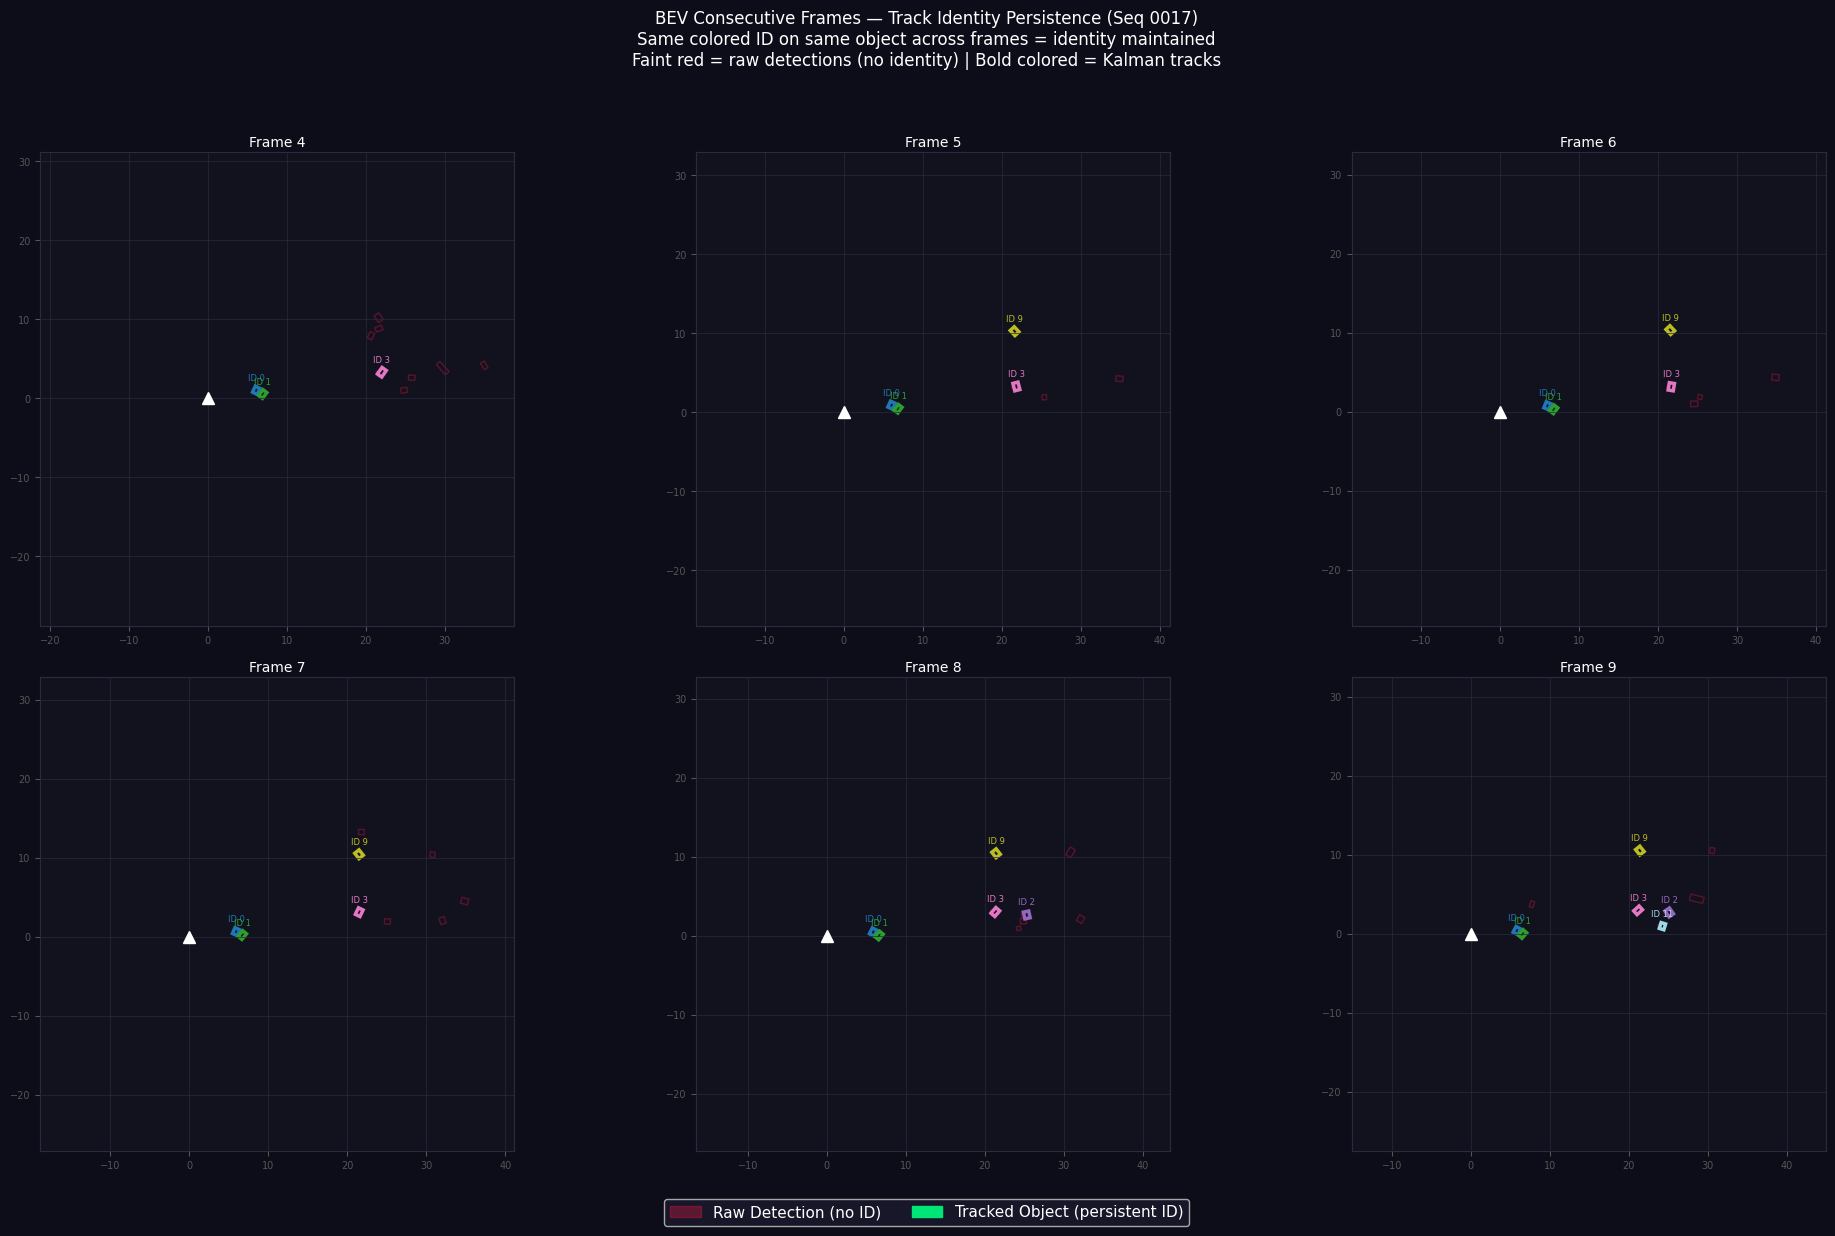

This plot shows the SAME track IDs persisting across consecutive frames.
Compare: faint red boxes (raw detections) have NO identity — they flicker independently.


In [ ]:
# Step 12b: BEV Consecutive Frames — Show track IDs persisting across frames
# This directly demonstrates IDENTITY MAINTENANCE: same color+ID on same object across frames
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Pick a sequence and consecutive frames
vis_seq = list(sequences.keys())[0]
seq_frame_list = sorted(sequences[vis_seq], key=lambda x: x['parsed_frame_num'])

# Find a window of 6 consecutive frames that have tracking results
N_SHOW = 6
vis_frames = []
for fd in seq_frame_list:
    fid = fd['frame_id']
    if len(tracking_results[vis_seq].get(fid, [])) > 0:
        vis_frames.append(fd)
    if len(vis_frames) >= N_SHOW:
        break

if len(vis_frames) < N_SHOW:
    vis_frames = seq_frame_list[:N_SHOW]

# Assign a consistent color to each track ID
all_track_ids = set()
for fd in vis_frames:
    for t in tracking_results[vis_seq].get(fd['frame_id'], []):
        all_track_ids.add(t['track_id'])

cmap = plt.cm.get_cmap('tab20', max(len(all_track_ids), 1))
id_to_color = {tid: cmap(i % 20) for i, tid in enumerate(sorted(all_track_ids))}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0d0d1a')
axes_flat = axes.flatten()

for ax_i, fd in enumerate(vis_frames):
    ax = axes_flat[ax_i]
    frame_id = fd['frame_id']
    frame_num = fd['parsed_frame_num']
    ax.set_facecolor('#12121f')
    ax.set_aspect('equal')
    ax.grid(True, color='#2a2a40', linewidth=0.5)
    ax.set_title(f'Frame {frame_num}', color='white', fontsize=10, pad=4)
    ax.tick_params(colors='#555555', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a40')

    # Draw raw detections (red, no ID) for comparison
    det_boxes = fd['boxes_lidar']
    det_names = fd['name']
    det_scores = fd.get('score', np.ones(len(det_boxes)))
    for det, name, score in zip(det_boxes, det_names, det_scores):
        if score >= score_thresholds.get(name, 0.5):
            draw_bev_box(ax, det[0], det[1], det[3], det[4], det[6],
                         color='#ff1744', lw=1.0, alpha=0.3)

    # Draw tracked objects (colored by ID) on top
    tracks = tracking_results[vis_seq].get(frame_id, [])
    for t in tracks:
        s = t['state']
        tid = t['track_id']
        color = id_to_color.get(tid, 'white')
        draw_bev_box(ax, s[0], s[1], s[3], s[4], s[6],
                     color=color, lw=2.5, alpha=1.0,
                     label=f"ID {tid}")

    # Ego-vehicle marker
    ax.plot(0, 0, marker='^', color='white', ms=8, zorder=10)

    # Auto-range based on content
    all_x = [t['state'][0] for t in tracks] + [0]
    all_y = [t['state'][1] for t in tracks] + [0]
    margin = 30
    cx, cy = np.mean(all_x), np.mean(all_y)
    ax.set_xlim(cx - margin, cx + margin)
    ax.set_ylim(cy - margin, cy + margin)

# Legend
det_patch = mpatches.Patch(color='#ff1744', alpha=0.3, label='Raw Detection (no ID)')
trk_patch = mpatches.Patch(color='#00e676', label='Tracked Object (persistent ID)')
fig.legend(handles=[det_patch, trk_patch], loc='lower center',
           ncol=2, fontsize=11, facecolor='#1a1a2e', labelcolor='white',
           framealpha=0.8, bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    f"BEV Consecutive Frames — Track Identity Persistence (Seq {vis_seq})\n"
    "Same colored ID on same object across frames = identity maintained\n"
    "Faint red = raw detections (no identity) | Bold colored = Kalman tracks",
    color='white', fontsize=12, y=1.03
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('/content/bev_track_identity.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("This plot shows the SAME track IDs persisting across consecutive frames.")
print("Compare: faint red boxes (raw detections) have NO identity — they flicker independently.")

/tmp/ipykernel_39636/1594378605.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(trajectory_history), 1))


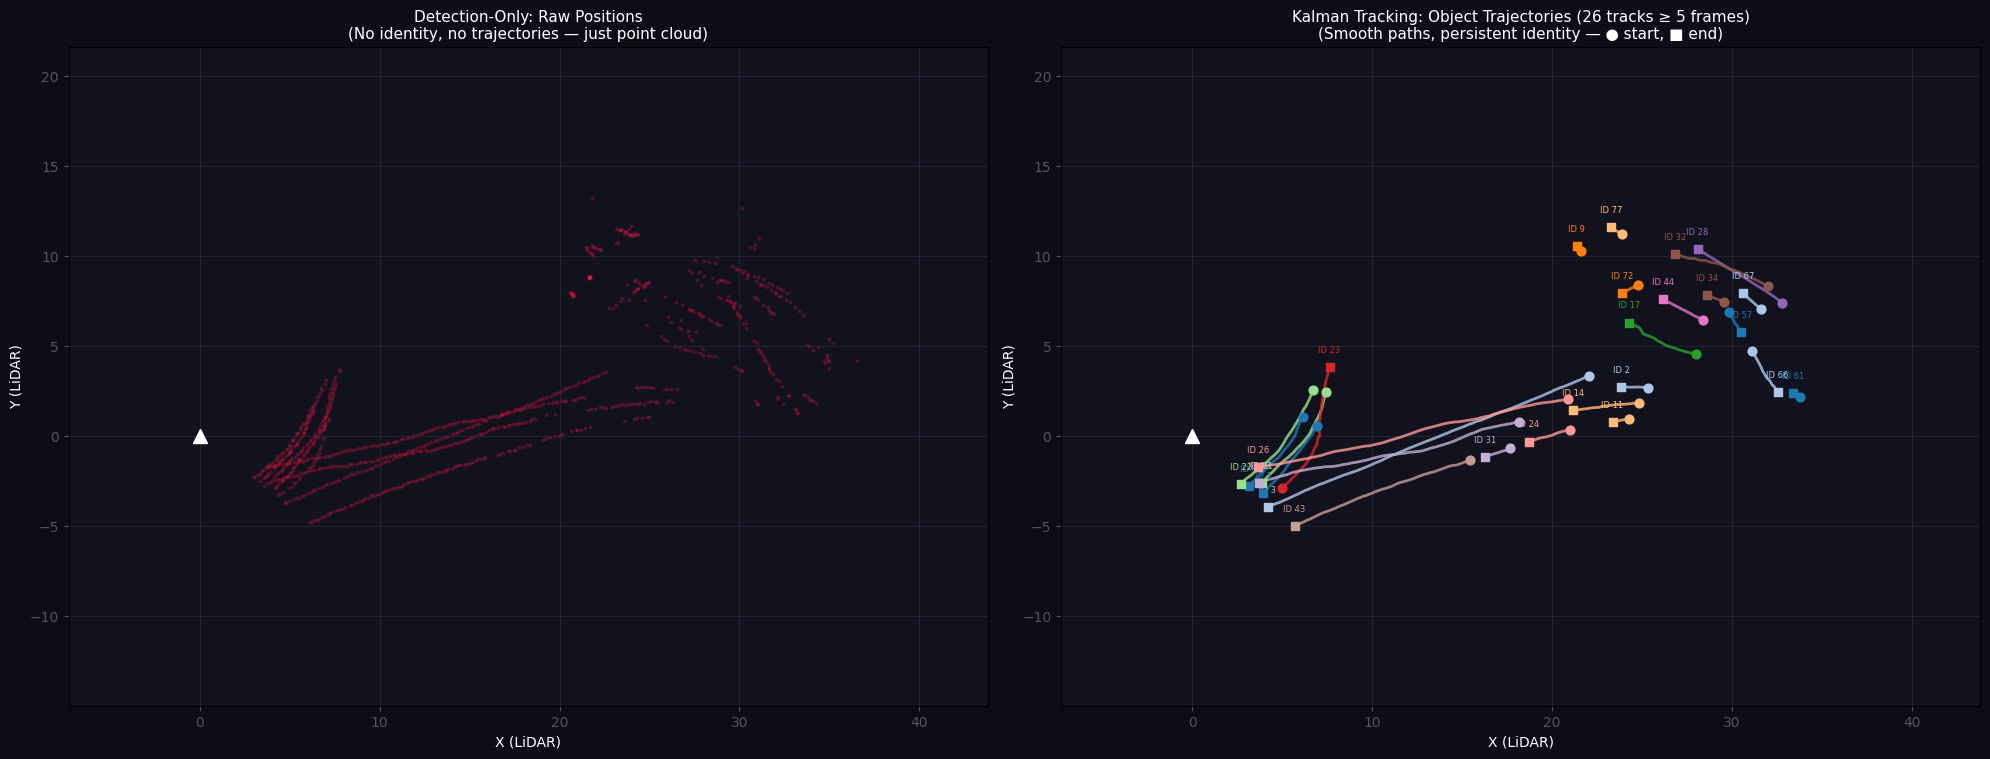


Total tracked objects: 32
Tracks with ≥ 5 frames (shown): 26

Left: Without tracking, detections are just a scatter cloud — no motion, no identity.
Right: With Kalman tracking, each object has a smooth trajectory with persistent ID.


In [ ]:
# Step 12c: BEV Trajectory Plot — Show smooth tracked paths over full sequence
# This demonstrates SMOOTH TRAJECTORIES and TEMPORAL CONSISTENCY
import matplotlib.pyplot as plt
import numpy as np

vis_seq = list(sequences.keys())[0]

# Collect trajectory histories: track_id -> list of (frame_num, x, y)
trajectory_history = {}
seq_frame_list = sorted(sequences[vis_seq], key=lambda x: x['parsed_frame_num'])

for fd in seq_frame_list:
    frame_id = fd['frame_id']
    frame_num = fd['parsed_frame_num']
    tracks = tracking_results[vis_seq].get(frame_id, [])
    for t in tracks:
        tid = t['track_id']
        s = t['state']
        if tid not in trajectory_history:
            trajectory_history[tid] = []
        trajectory_history[tid].append((frame_num, s[0], s[1]))

# Also collect raw detection positions for comparison (no identity)
raw_det_positions = []
for fd in seq_frame_list:
    frame_num = fd['parsed_frame_num']
    for det, name, score in zip(fd['boxes_lidar'], fd['name'], fd.get('score', np.ones(len(fd['boxes_lidar'])))):
        if score >= score_thresholds.get(name, 0.5):
            raw_det_positions.append((frame_num, det[0], det[1]))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: Raw detections (no identity — just a scatter cloud)
ax1 = axes[0]
ax1.set_facecolor('#12121f')
if raw_det_positions:
    xs = [p[1] for p in raw_det_positions]
    ys = [p[2] for p in raw_det_positions]
    ax1.scatter(xs, ys, c='#ff1744', s=3, alpha=0.2)
ax1.plot(0, 0, marker='^', color='white', ms=10, zorder=10)
ax1.set_title("Detection-Only: Raw Positions\n(No identity, no trajectories — just point cloud)",
              color='white', fontsize=11)
ax1.set_xlabel("X (LiDAR)", color='white')
ax1.set_ylabel("Y (LiDAR)", color='white')
ax1.tick_params(colors='#555555')
ax1.set_aspect('equal')
ax1.grid(True, color='#2a2a40', linewidth=0.5)

# Right: Tracked trajectories (smooth paths with identity)
ax2 = axes[1]
ax2.set_facecolor('#12121f')
cmap = plt.cm.get_cmap('tab20', max(len(trajectory_history), 1))
long_tracks = {tid: pts for tid, pts in trajectory_history.items() if len(pts) >= 5}

for i, (tid, points) in enumerate(sorted(long_tracks.items())):
    pts = sorted(points, key=lambda p: p[0])
    xs = [p[1] for p in pts]
    ys = [p[2] for p in pts]
    color = cmap(i % 20)
    ax2.plot(xs, ys, color=color, lw=2.0, alpha=0.8)
    ax2.scatter(xs[0], ys[0], color=color, s=40, marker='o', zorder=5)   # start
    ax2.scatter(xs[-1], ys[-1], color=color, s=40, marker='s', zorder=5)  # end
    ax2.text(xs[-1], ys[-1] + 0.8, f"ID {tid}", color=color, fontsize=6, ha='center')

ax2.plot(0, 0, marker='^', color='white', ms=10, zorder=10)
ax2.set_title(f"Kalman Tracking: Object Trajectories ({len(long_tracks)} tracks ≥ 5 frames)\n"
              "(Smooth paths, persistent identity — ● start, ■ end)",
              color='white', fontsize=11)
ax2.set_xlabel("X (LiDAR)", color='white')
ax2.set_ylabel("Y (LiDAR)", color='white')
ax2.tick_params(colors='#555555')
ax2.set_aspect('equal')
ax2.grid(True, color='#2a2a40', linewidth=0.5)

# Match axis limits
all_x = [p[1] for pts in trajectory_history.values() for p in pts]
all_y = [p[2] for pts in trajectory_history.values() for p in pts]
if all_x and all_y:
    margin = 10
    xlim = (min(all_x) - margin, max(all_x) + margin)
    ylim = (min(all_y) - margin, max(all_y) + margin)
    ax1.set_xlim(xlim); ax1.set_ylim(ylim)
    ax2.set_xlim(xlim); ax2.set_ylim(ylim)

fig.patch.set_facecolor('#0d0d1a')
plt.tight_layout()
plt.savefig('/content/bev_trajectories.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print(f"\nTotal tracked objects: {len(trajectory_history)}")
print(f"Tracks with ≥ 5 frames (shown): {len(long_tracks)}")
print("\nLeft: Without tracking, detections are just a scatter cloud — no motion, no identity.")
print("Right: With Kalman tracking, each object has a smooth trajectory with persistent ID.")